In [17]:
#%load_ext autoreload
#%autoreload 2
import numpy as np
import pickle
import matplotlib.pyplot as plt

import kwant
from scipy import linalg as la
from alter_morph.kwant_utilities import crack_hamiltonian_for_contacts_kwant, attach_leads_to_cracked

#from scipy import linalg as la
from alter_morph.hamiltonians import alt_hamiltonian
# from alter_morph.lattice_utilities import alter_lattice_maker,add_contacts
# from alter_morph.mean_field import hartree_fock
# from alter_morph.kwant_utilities import Amorphous

In [ ]:
import sys,os

d = pickle.load(open(os.getcwd()[:-8]+'data/full_phase_diagram_20_V1.pickle','rb'))

print(d.keys())
print('fillings: ', d['filling'].shape)
print('Js: ', d['J'].shape)
print('params:', d['params'].shape)
print('\t element [0,0]', d['params'][0,0].keys())
print('data:', d['data'].shape)
print('\t element [0,0]', d['data'][0,0].keys())
print('\t element [0,0] numerical params', d['data'][0,0]['numerical_param'].keys())

Js = d['J']
ns = d['filling']


dict_keys(['filling', 'J', 'data', 'params'])
fillings:  (31,)
Js:  (51,)
params: (31, 51)
	 element [0,0] dict_keys(['t1', 't2', 'J', 'filling', 'theta_offset', 'm'])
data: (31, 51)
	 element [0,0] dict_keys(['hparam', 'numerical_param'])
	 element [0,0] numerical params dict_keys(['m_values', 'iteration_steps', 'learning_rate', 'tol_mdiff'])
200


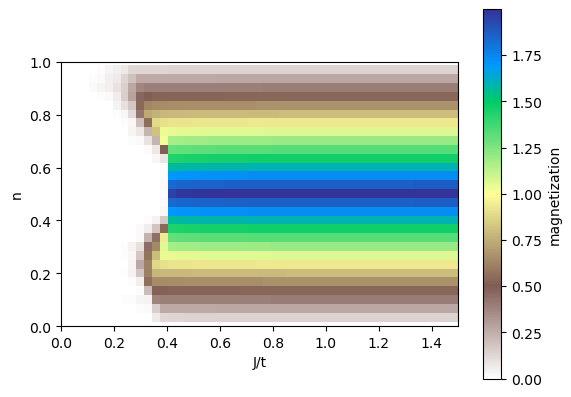

In [4]:
array_magnetization = np.array([[params['m'] for params in x]for x in d['params']]) #.shape (filling, Js, vertices)

fig, ax = plt.subplots(1,1)

#ax.set_title('T/t={0}; Lq={1}'.format(T,Lq))
ax.set_xlabel('J/t')
ax.set_ylabel('n')
ax.set_xlim(Js[0],Js[-1])
ax.set_ylim(ns[0],ns[-1])

extent=[Js[0]-(Js[1]-Js[0])/2,Js[-1]+(Js[1]-Js[0])/2,ns[0]-(ns[1]-ns[0])/2,ns[-1]+(ns[1]-ns[0])/2] #the correct extent

im = ax.imshow(array_magnetization.mean(axis=-1),origin='lower',interpolation='none',extent=extent,cmap='terrain_r')
cbar = fig.colorbar(im, ax=ax,shrink=1)
cbar.set_label('magnetization')


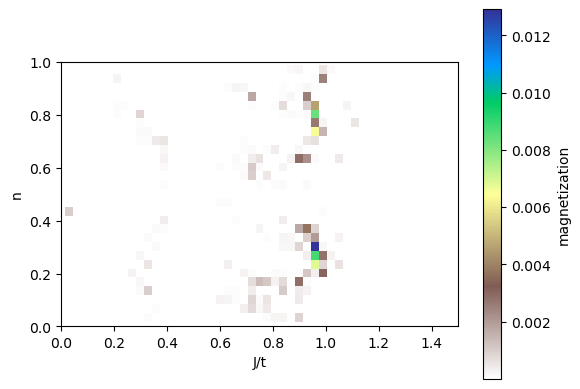

In [14]:
#check convergence

iterations = np.array([[params['numerical_param']['m_values'].shape[0] for params in x]for x in d['data']]) #.shape (filling, Js, vertices)
diffs = np.array([[params['numerical_param']['m_values'][-2] - params['numerical_param']['m_values'][-1] for params in x]for x in d['data']]) #.shape (filling, Js, vertices)
diffs = np.abs(diffs).mean(axis=-1)

fig, ax = plt.subplots(1,1)

#ax.set_title('T/t={0}; Lq={1}'.format(T,Lq))
ax.set_xlabel('J/t')
ax.set_ylabel('n')
ax.set_xlim(Js[0],Js[-1])
ax.set_ylim(ns[0],ns[-1])

extent=[Js[0]-(Js[1]-Js[0])/2,Js[-1]+(Js[1]-Js[0])/2,ns[0]-(ns[1]-ns[0])/2,ns[-1]+(ns[1]-ns[0])/2] #the correct extent

im = ax.imshow(diffs,origin='lower',interpolation='none',extent=extent,cmap='terrain_r')
cbar = fig.colorbar(im, ax=ax,shrink=1)
cbar.set_label('magnetization')


In [23]:
#calculate spin conductance

lattice = pickle.load(open('voronoi_20.pickle','rb'))


lead_symmetry = np.diag([-1,-1,1,1])
for data_column in d['data']:
    for data_entry in data_column:

        hamiltonian = alt_hamiltonian(
            lattice,
            data_entry['hparam']["t1"],
            data_entry['hparam']["t2"],
            data_entry['hparam']["J"],
            data_entry['hparam']['m'],
            theta_offset = data_entry['hparam']['theta_offset']
        )

        n_orbitals = 4
        lead_onsite = np.eye(n_orbitals)
        lead_coupling = np.eye(n_orbitals)

        contact_lattice, k_lattice, k_system, contact_vertices = (
            crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
        )
        kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
            contact_lattice, k_lattice, k_system, contact_vertices, lead_onsite, lead_coupling, lead_symmetry
        )

        k_system_f = k_system.finalized()
        smatrix = kwant.smatrix(k_system_f)
        g = np.array([[smatrix.transmission((1,j),(0,i)) for j in range(2)] for i in range(2)])
        data_entry['spin_cond'] = g

AssertionError: lattice must have open boundaries in y

In [1]:
import scipy 
scipy.__version__

'1.13.1'